# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "ch2cl2"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[11.0 10.933333333333334 10.866666666666667 ... 28.633333333333333 31.5 31.5] [11.0 10.933333333333334 10.963636363636363 ... 33.449999999999996 31.5 31.5] [11.0 10.981818181818182 12.8 ... 33.45 31.5 31.5] [11.0 13.2 15.399999999999999 ... 33.45 31.5 31.5] [11.0 10.933333333333334 12.0 ... 32.40909090909091 31.5 31.5] [11.0 10.933333333333334 10.866666666666667 ... 30.327272727272724 31.5 31.5]] [[10.4 10.366666666666667 10.333333333333334 ... 30.225 32.7125 35.2] [10.4 10.366666666666667 10.327272727272728 ... 51.400000000000006 43.300000000000004 35.2] [10.4 10.363636363636365 13.850000000000003 ... 28.974999999999998 32.50416666666667 35.2] [10.4 14.854545454545454 19.30909090909091 ... 29.808333333333334 32.712500000000006 35.2] [10.4 10.366666666666667 12.57727272727273 ... 30.224999999999998 32.712500000000006 35.2] [10.4 10.366666666666667 10.333333333333334 ... 30.225000000000005 32.7125 35.2]] [[8.6 8.433333333333334 8.266666666666666 ... 38.78333333333333 44.3 45.0] [8.6 8.433333333333334 8.49090909090909 ... 60.35 52.675000000000004 45.0] [8.6 8.545454545454545 12.958928571428574 ... 35.775 40.82222222222222 45.0] [8.6 13.956818181818182 19.313636363636363 ... 36.644444444444446 41.69166666666666 45.0] [8.6 8.433333333333334 11.028409090909092 ... 37.51388888888889 42.56111111111111 45.0] [8.6 8.433333333333334 8.266666666666666 ... 38.38333333333333 43.43055555555556 45.0]] ... [[26.3 26.900000000000002 27.500000000000004 ... 82.84583333333333 77.825 76.925] [26.3 26.900000000000002 27.436363636363637 ... 76.95 76.9375 76.925] [26.3 26.86818181818182 30.652678571428574 ... 80.45 78.59166666666667 76.925] [26.3 31.54285714285714 36.78571428571429 ... 77.92777777777779 78.4 76.925] [26.3 26.9 29.82142857142857 ... 75.40555555555557 78.20833333333333 76.925] [26.3 26.900000000000002 27.5 ... 72.88333333333333 78.01666666666667 76.925]] [[26.2 26.541666666666668 26.883333333333336 ... 73.9625 74.4 73.4] [26.2 26.541666666666664 31.173684210526318 ... 83.16666666666667 78.28333333333333 73.4] [26.2 28.686842105263157 37.60921052631579 ... 74.6 74.04444444444444 73.4] [26.2 30.85833333333333 35.516666666666666 ... 72.80092592592592 74.13333333333334 73.4] [26.2 26.541666666666664 29.041666666666664 ... 71.00185185185185 74.22222222222221 73.4] [26.2 26.541666666666668 26.883333333333333 ... 69.20277777777777 74.31111111111112 73.4]] [[26.25 26.46666666666667 26.683333333333334 ... 79.59333333333333 76.72 76.97999999999999] [26.25 26.466666666666665 32.20789473684211 ... 76.6 76.78999999999999 76.97999999999999] [26.25 29.22894736842105 40.49473684210527 ... 78.55000000000001 77.64888888888889 76.97999999999999] [26.25 31.26190476190476 36.273809523809526 ... 76.23037037037038 77.41666666666667 76.97999999999999] [26.25 26.466666666666665 29.08095238095238 ... 73.91074074074075 77.18444444444444 76.97999999999999] [26.25 26.466666666666665 26.68333333333333 ... 71.5911111111111 76.95222222222222 76.97999999999999]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[13.65 13.65 13.442416666666666 ... 63.37049999999999 65.475 63.86749999999999] [13.65 13.65 22.19761904761905 ... 66.06666666666666 65.89583333333333 65.725] [13.65 13.65 17.206851851851848 ... 64.45 64.8 62.01] [13.65 13.65 13.442416666666666 ... 53.616 55.9555 58.295] [13.65 13.65 13.442416666666668 ... 60.966750000000005 61.515857142857136 60.1525] [13.65 13.65 13.442416666666668 ... 64.73671428571429 63.49542857142857 62.01]] [[14.1 14.099999999999998 13.564 ... 63.652 66.95 64.99875] [14.1 14.1 21.610714285714288 ... 67.2 66.975 66.75] [14.1 14.099999999999998 16.934333333333328 ... 64.3 67.35 63.2475] [14.1 14.1 13.564 ... 57.089 58.417 59.745] [14.1 14.1 13.564000000000002 ... 61.976 62.42857142857142 61.496249999999996] [14.1 14.1 13.564 ... 65.11214285714286 64.68928571428572 63.2475]] [[13.4 13.4 13.432916666666667 ... 67.172 68.8 66.859] [13.4 13.4 21.735119047619047 ... 69.925 69.6625 69.39999999999999] [13.4 13.4 16.320518518518515 ... 63.2 65.9 64.318] [13.4 13.4 13.432916666666667 ... 57.038 58.137 59.236] [13.4 13.4 13.432916666666666 ... 63.47449999999999 63.33828571428571 61.776999999999994] [13.4 13.4 13.432916666666666 ... 67.44057142857143 66.06914285714286 64.318]] ... [[26.3 26.900000000000002 27.500000000000004 ... 82.84583333333333 77.825 76.925] [26.3 26.900000000000002 27.436363636363637 ... 76.95 76.9375 76.925] [26.3 26.86818181818182 30.652678571428574 ... 80.45 78.59166666666667 76.925] [26.3 31.54285714285714 36.78571428571429 ... 77.92777777777779 78.4 76.925] [26.3 26.9 29.82142857142857 ... 75.40555555555557 78.20833333333333 76.925] [26.3 26.900000000000002 27.5 ... 72.88333333333333 78.01666666666667 76.925]] [[26.2 26.541666666666668 26.883333333333336 ... 73.9625 74.4 73.4] [26.2 26.541666666666664 31.173684210526318 ... 83.16666666666667 78.28333333333333 73.4] [26.2 28.686842105263157 37.60921052631579 ... 74.6 74.04444444444444 73.4] [26.2 30.85833333333333 35.516666666666666 ... 72.80092592592592 74.13333333333334 73.4] [26.2 26.541666666666664 29.041666666666664 ... 71.00185185185185 74.22222222222221 73.4] [26.2 26.541666666666668 26.883333333333333 ... 69.20277777777777 74.31111111111112 73.4]] [[26.25 26.46666666666667 26.683333333333334 ... 79.59333333333333 76.72 76.97999999999999] [26.25 26.466666666666665 32.20789473684211 ... 76.6 76.78999999999999 76.97999999999999] [26.25 29.22894736842105 40.49473684210527 ... 78.55000000000001 77.64888888888889 76.97999999999999] [26.25 31.26190476190476 36.273809523809526 ... 76.23037037037038 77.41666666666667 76.97999999999999] [26.25 26.466666666666665 29.08095238095238 ... 73.91074074074075 77.18444444444444 76.97999999999999] [26.25 26.466666666666665 26.68333333333333 ... 71.5911111111111 76.95222222222222 76.97999999999999]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'ch2cl2' (lon: 6, lat: 12, year: 10, month: 12)> Size: 69kB
<Quantity([[[[ 13.65        14.1         13.4        ...  19.33333333
     19.1         15.2       ]
   [ 13.8         13.03333333  13.73333333 ...  18.7
     16.9         15.3       ]
   [ 13.5         13.53333333  13.75       ...  19.
     17.63333333  16.05      ]
   ...
   [ 15.86666667  15.925       17.5        ...  24.5
     22.46666667  20.5       ]
   [ 18.125       17.575       17.9        ...  24.15
     22.2         19.6       ]
   [ 17.8         17.3         18.2        ...  24.66666667
     22.83333333  21.55      ]]

  [[ 13.65        14.1         13.4        ...  19.33333333
     19.1         15.8104    ]
   [ 14.6311      13.72673333  13.75066667 ...  18.7
     16.91111111  14.971     ]
   [ 13.40033333  13.29244444  13.84595    ...  18.849
     17.43345     16.1321    ]
...
   [ 77.78191667  81.92233333  84.69108333 ...  66.20875
     74.21966667  81.83158333]
   [ 88.01566667  88.26666667  89.2725     ...  62.24530556
     70.97841667  77.471     ]
   [ 82.61441667  83.9855      88.75211111 ...  68.014
     78.8785      90.81466667]]

  [[ 62.01        63.2475      64.318      ...  49.7525
     54.262       61.1625    ]
   [ 63.705       65.85483333  65.55       ...  49.4
     57.6         63.13333333]
   [ 66.5         69.575       66.785      ...  49.4025
     54.6855      65.765     ]
   ...
   [ 76.0365      81.05        82.75416667 ...  64.61833333
     71.4875      80.9635    ]
   [ 86.262       86.16433333  88.0385     ...  61.58
     67.849       75.4375    ]
   [ 81.6405      82.6785      88.12266667 ...  64.875
     75.266       90.5365    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 80B 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.099999999999998 13.4 ... 24.316499999999998 22.908466666666666 21.564883333333334] [13.442416666666666 13.564 13.432916666666667 ... 23.865833333333335 22.559 20.87441666666667] ... [63.37049999999999 63.652 67.172 ... 70.82391666666668 81.37866666666667 91.98] [65.475 66.95 68.8 ... 69.46000000000001 80.0 93.4] [63.86749999999999 64.99875 66.859 ... 66.53750000000001 77.303 93.34325000000001]] [[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.1 13.4 ... 24.35 23.05 21.8] [22.19761904761905 21.610714285714288 21.735119047619047 ... 32.607142857142854 32.65833333333333 32.70119047619048] ... [66.06666666666666 67.2 69.925 ... 75.15 94.9 98.65] [65.89583333333333 66.975 69.6625 ... 71.67500000000001 87.12 97.4] [65.725 66.75 69.39999999999999 ... 68.2 79.34 96.15]] [[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.099999999999998 13.4 ... 27.01278431372549 25.89012745098039 25.449454545454543] [17.206851851851848 16.934333333333328 16.320518518518515 ... 32.021686274509804 31.787049019607842 32.998363636363635] ... [64.45 64.3 63.2 ... 67.084 73.0655 95.65] [64.8 67.35 65.9 ... 75.9 84.69999999999999 96.2] [62.01 63.2475 64.318 ... 64.875 75.26599999999999 90.5365]] [[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.1 13.4 ... 30.093833333333336 29.917916666666663 29.134562499999994] [13.442416666666666 13.564 13.432916666666667 ... 35.521 37.0025 36.719125] ... [53.616 57.089 57.038 ... 68.694 82.07900000000001 86.36500000000001] [55.9555 58.417 58.137 ... 65.122 76.63550000000001 85.644] [58.295 59.745 59.236 ... 61.55 71.192 84.923]] [[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.1 13.4 ... 24.2495 22.6254 21.094649999999998] [13.442416666666668 13.564000000000002 13.432916666666666 ... 26.737750000000002 25.992958333333334 24.541697916666664] ... [60.966750000000005 61.976 63.47449999999999 ... 69.40397222222222 81.84555555555555 88.23666666666666] [61.515857142857136 62.42857142857142 63.33828571428571 ... 66.56800000000001 77.757 88.22933333333334] [60.1525 61.496249999999996 61.776999999999994 ... 63.2125 73.229 87.72975]] [[13.65 14.1 13.4 ... 24.666666666666668 22.833333333333332 21.549999999999997] [13.65 14.1 13.4 ... 24.283000000000005 22.766933333333334 21.329766666666664] [13.442416666666668 13.564 13.432916666666666 ... 23.832333333333334 22.41746666666667 20.6393] ... [64.73671428571429 65.11214285714286 67.44057142857143 ... 70.11394444444444 81.61211111111112 90.10833333333333] [63.49542857142857 64.68928571428572 66.06914285714286 ... 68.01400000000001 78.8785 90.81466666666667] [62.01 63.2475 64.318 ... 64.875 75.26599999999999 90.5365]]]
Units,ppt


### Longitudinal-mean

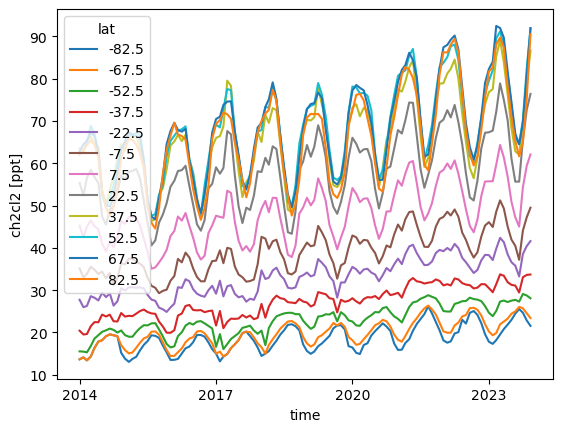

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

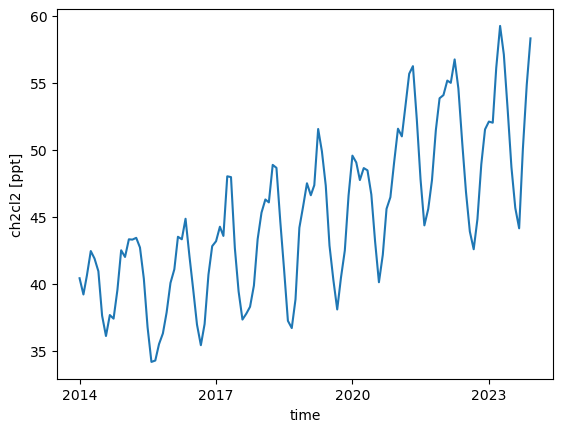

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

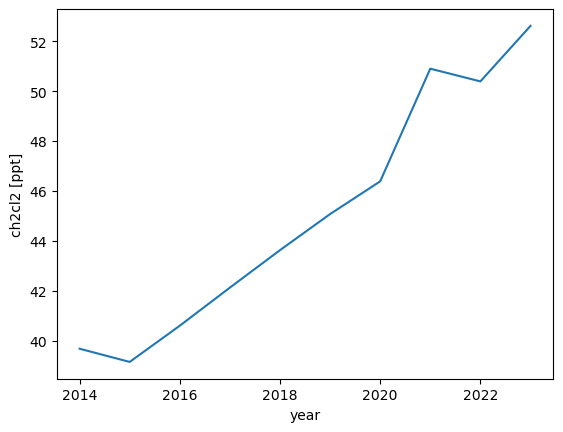

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[-0.39641746933373684 0.13585266732208745 0.6091619154648088 -0.05432559122468436 -0.38430998598118593 0.22834642679642594 0.08414999491504717 -0.4023759359305597 0.2804817727942449 -0.0019323801452862145] [-0.3781932141174224 -0.027497302439112695 0.3581828886501742 -0.2702432742756698 0.009172163718111219 -0.045892297460218466 -0.1546444846001091 0.4988272514080169 -0.5718510348813898 -0.14713945085202526] [-0.33061383968625707 -0.21084779508546433 -0.04533823054832821 -0.3263530042907952 0.35814762279129697 -0.15101366700756164 0.13367782992530852 0.018127223533050667 0.22983478290102105 0.6581143709868673] [-0.2675872418613833 -0.23319887550004514 -0.18914578556179806 -0.10388216042029622 0.1700856116099975 -0.1393053437434023 0.0899297368822942 -0.10891924452026949 0.22925162427424237 -0.6923276565510319] [-0.17893692569976194 -0.18065288066537946 -0.21952523528681062 0.1529738105804063 -0.08425335680478818 -0.16000820488505052 -0.03746628259380542 -0.20238910234352844 -0.0109673455569073 -0.027672472911627267] [-0.08873616455922444 -0.07207385444174887 -0.16955568787984507 0.43027456774357553 -0.41244599855659064 -0.06574581805230044 -0.2850098804580238 -0.10556652343118803 -0.2828237917665646 0.2526938463628925] [0.04551948155996551 0.15369402371458088 0.02340618557339111 0.3247364529023767 0.03465320312868708 0.4666068450674196 0.21185044402029865 0.5668645233690318 0.3412983977054796 0.003925943482653782] [0.20029268651012583 0.32088866965158575 0.0632838638755288 -0.06369579131058993 0.45642676762905054 0.3396291631491909 0.12590284196708112 -0.4408250823204567 -0.4146193984997738 -0.011136111859458219] [0.31369037807480477 0.4625498954832005 0.28148828194496933 -0.06776664059618549 0.04310643672717971 -0.5917196516879887 -0.2701745433076958 0.0735330731685113 0.2603325059222751 -0.02654038352263295] [0.3458357762247553 -0.04804598831429779 -0.14471956014463316 -0.516061050771561 -0.5355328826816784 -0.025662964664576047 0.47690820655318855 0.049808017861292804 -0.10481456469391083 0.018365683985532354] [0.34702344863899737 -0.44454110340305086 0.12503935478688588 -0.30681185668096134 -0.005375029172943649 0.370518638858909 -0.6145684973226108 -0.03154740452723762 0.17445517029630994 -0.010196924764826408] [0.3136935044498136 -0.5510447644888813 0.5152549798923459 0.3516056982441655 0.14001349323259035 -0.22906516484727324 0.34864034789672743 -0.02054289360241878 -0.10601367633687317 0.003016494375374027]]
Units,ppt
Magnitude,[[61.05155680013885 3.0487744961151493 1.3492729022832939 0.604355388451124 0.16454513755811276 0.21412551971059365 0.02801404954315562 0.02009489238852644 0.01462227387269865 -0.0025225003952699054] [57.995211241316795 0.11329078758167657 0.5692388173959669 -0.3538549889760135 0.45992643147091944 -0.42750656637113194 -0.013916013335108003 0.03991888130364007 -0.02401909515745384 -0.004699613281185393] [60.6363193529885 0.4878691134143525 0.0910398220007155 -0.0018614573316848182 0.42671295604266657 -0.30276455967938903 -0.002279734990608961 -0.06853404406298709 0.018886499736088316 0.006136081759611037] [68.32857840523494 0.5951312596875642 2.547753567852793 -0.43808167217107136 -0.5192095595024426 -0.025265599098249734 -0.01526782764342311 0.0013117738284843003 -0.009721930970887563 0.003222207754446117] [62.34044305133723 -0.6285415229537683 -0.502325238489353 0.6424620198358904 -0.35005731093341486 -0.2595437456944325 -0.08858518294116606 -0.047494092021399203 -0.020819214661216782 -0.002883569365660333] [65.23334927559844 1.7115738827984837 -1.958361464804647 -0.23863146796078835 0.06084421797970257 0.29895349163952295 -0.1347105041240661 0.023658238985479967 -0.014647153923188104 0.0029269554708557916] [68.21519211368125 0.3804697710948137 -1.4872402286940622 -0.27202274357179795 -0.3515476347131542 -0.24910154685885058 0.025560143039615867 0.020940629249596693 0.04441641887394315 -0.002974942366194673] [73.6970239437743 -0.06087659617863366 -1.2684261270369517 0.134912697016234

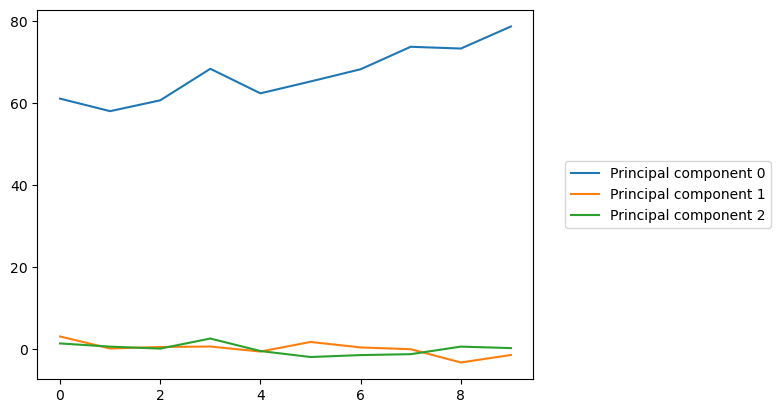

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

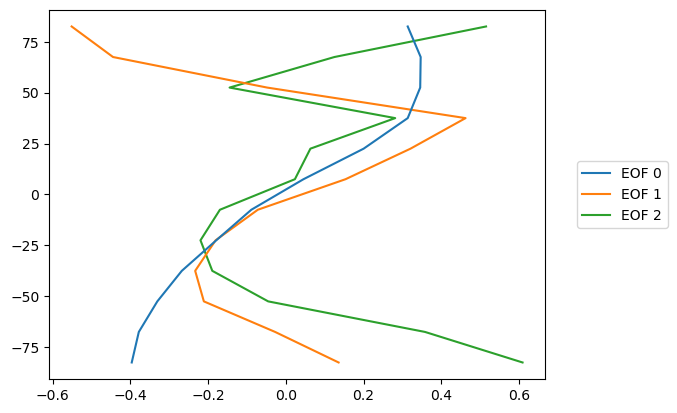

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

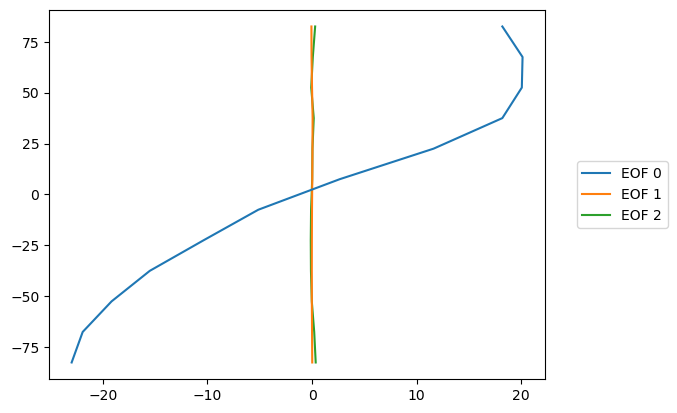

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[-0.39641746933373684] [-0.3781932141174224] [-0.33061383968625707] [-0.2675872418613833] [-0.17893692569976194] [-0.08873616455922444] [0.04551948155996551] [0.20029268651012583] [0.31369037807480477] [0.3458357762247553] [0.34702344863899737] [0.3136935044498136]]
Units,ppt
Magnitude,[[61.05155680013885] [57.995211241316795] [60.6363193529885] [68.32857840523494] [62.34044305133723] [65.23334927559844] [68.21519211368125] [73.6970239437743] [73.26425363923919] [78.64524931077129]]
Units,dimensionless


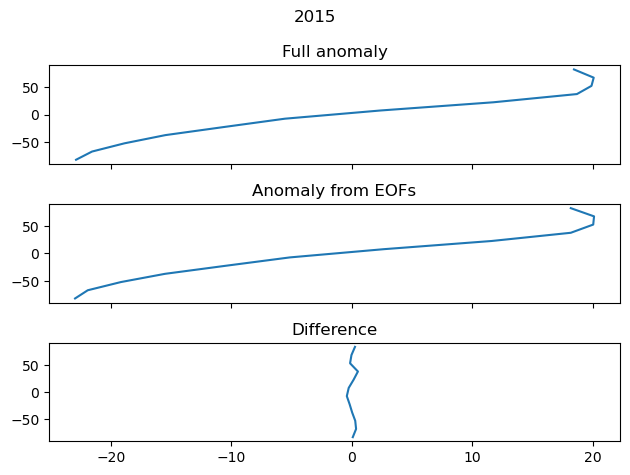

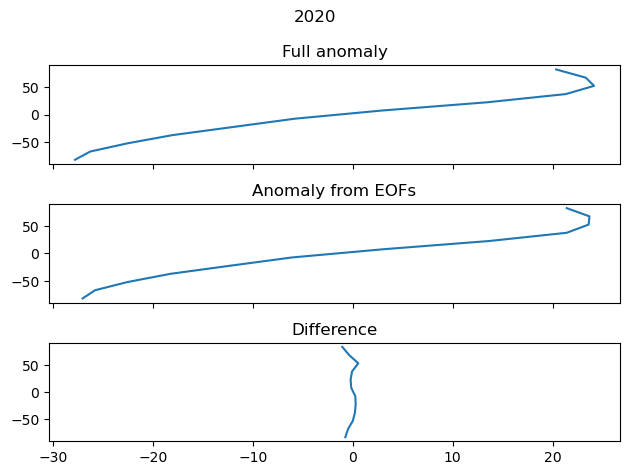

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/120 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 16944.40it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/120 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/120 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 19388.90it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/120 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 19821.07it/s]

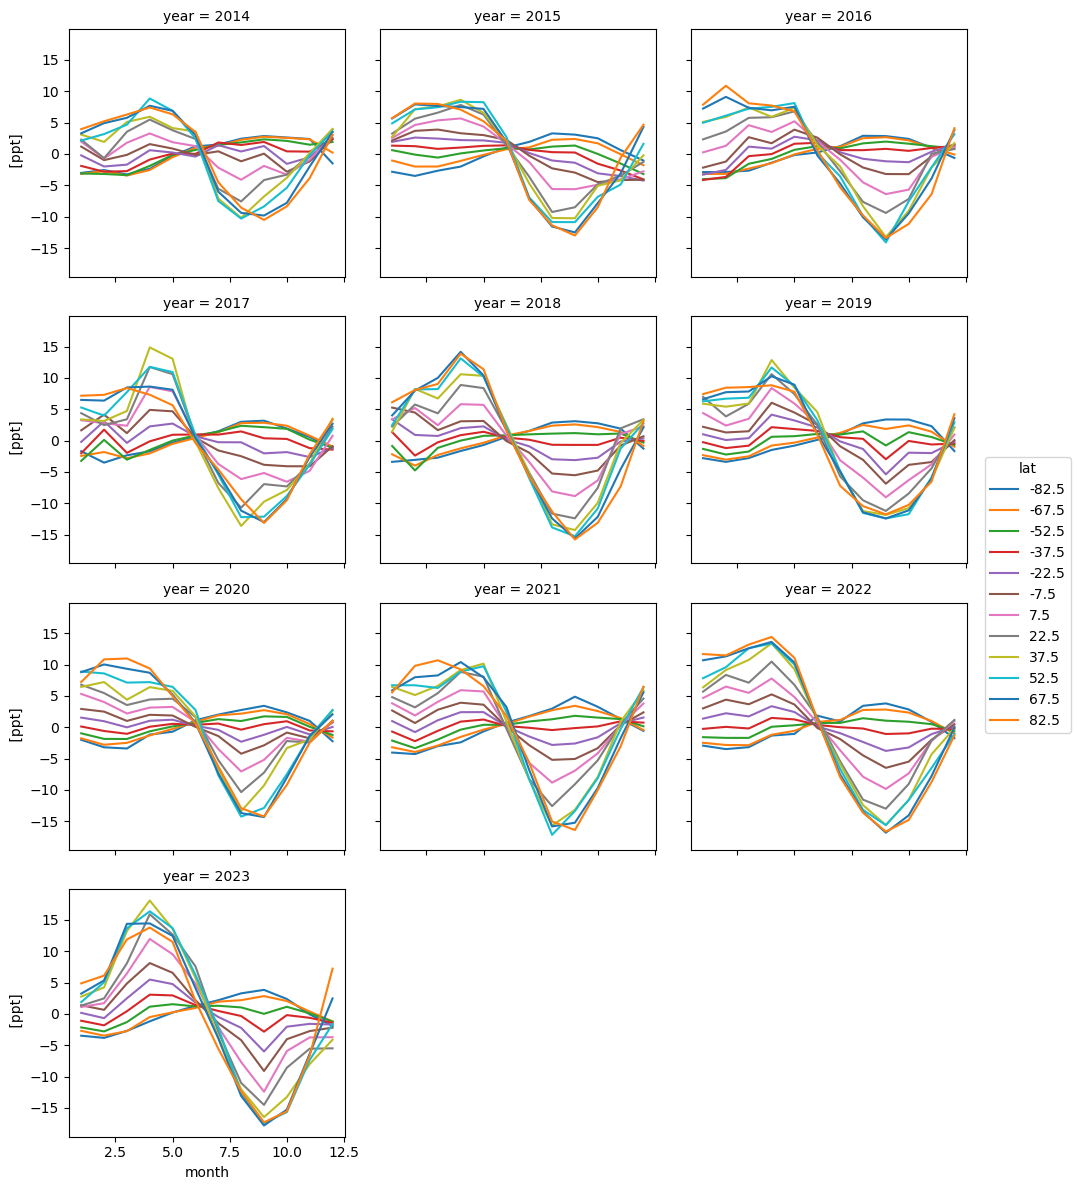

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

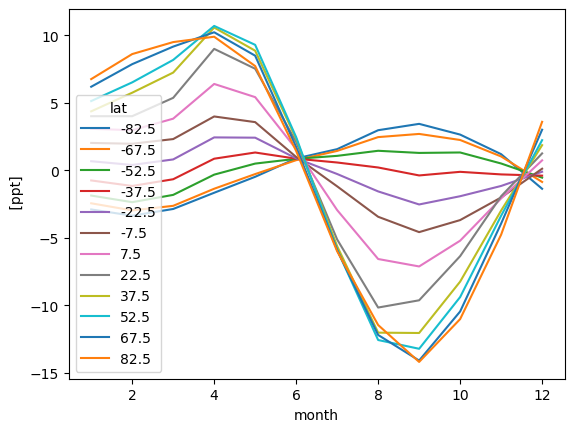

In [22]:
seasonality.plot.line(hue="lat")

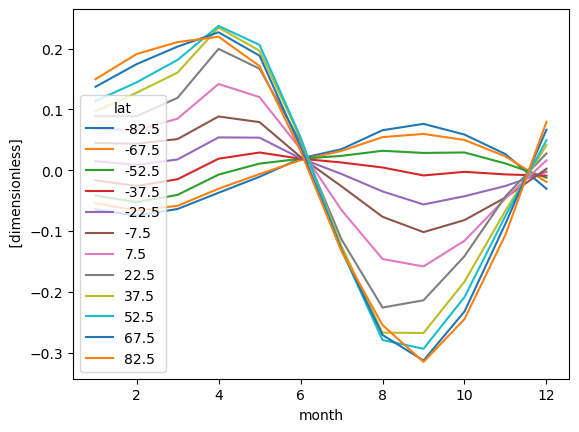

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[39.68820061296835 39.15936054549226 40.608969569092366 42.133831587270265 43.63373685966619 45.078172395358195 46.38817674989335 50.89862956576644 50.389596128296056 52.610166601302524]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[-0.39641746933373684] [-0.3781932141174224] [-0.33061383968625707] [-0.2675872418613833] [-0.17893692569976194] [-0.08873616455922444] [0.04551948155996551] [0.20029268651012583] [0.31369037807480477] [0.3458357762247553] [0.34702344863899737] [0.3136935044498136]]
Units,ppt
Magnitude,[[61.05155680013885] [57.995211241316795] [60.6363193529885] [68.32857840523494] [62.34044305133723] [65.23334927559844] [68.21519211368125] [73.6970239437743] [73.26425363923919] [78.64524931077129]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.06451870186373543 -0.07475058346096251 -0.06372353327900945 -0.037048132115884924 -0.010791898132604782 0.019406724171624715 0.03469131515860571 0.06583323098977373 0.07628953000963748 0.058654311560788014 0.026452764791454936 -0.030495158665006704] [-0.05437268113429497 -0.06607406094557369 -0.058550982743281126 -0.030435207737449958 -0.006321675338421782 0.01656509598052384 0.031784077996079914 0.05450374535340157 0.05972333391886381 0.049782558156456116 0.02268894816806018 -0.01929325343283924] [-0.04164403662664035 -0.0525483025346291 -0.04054938495693852 -0.007241008770390496 0.010929601690957889 0.01878939384517985 0.023647190983518213 0.032007207266483796 0.028479829691783174 0.029220949138615882 0.01109584618515621 -0.01218743344705418] [-0.01677236781488912 -0.025860955070418336 -0.014820026431519927 0.01897006494490678 0.029161452464243075 0.019002710093010012 0.012730388786346393 0.0045254767827075035 -0.008564516688402364 -0.002620963983710629 -0.006860088344833421 -0.00889138481410542] [0.01482585248288131 0.008682448994765906 0.017785428000373388 0.05400695737082733 0.053556738326624935 0.01956783042997354 -0.006190311216356032 -0.03482981645203272 -0.05630507812451159 -0.04275190938802994 -0.025859624998465502 -0.0024888178195259176] [0.04491440409965193 0.04356979754205213 0.05125582520983382 0.08844554878022293 0.07914878269240493 0.02185082858895101 -0.026495604631515585 -0.07654911392701555 -0.10179917095179383 -0.08201196936769338 -0.04481271081483448 0.0024829783520675364] [0.06821671801304688 0.06582561408296918 0.0848274440226198 0.14194701342266602 0.12025648421009258 0.03482589919598786 -0.06555120013799462 -0.14603017265762466 -0.15827270844808808 -0.11590739467374887 -0.04635970240142384 0.0162213738517545] [0.08886680813011548 0.08890431537732615 0.11909081207456124 0.19964438047317515 0.16696834834391763 0.046618038654654685 -0.1138446113188669 -0.22587209201125302 -0.21394645486557592 -0.14134242486348156 -0.042780263219088704 0.02769225751879155] [0.09686569868814938 0.1275082177722367 0.16063993859801823 0.23473007919975436 0.1966557777903954 0.05177611387503659 -0.12488915297155316 -0.267177121212761 -0.26772911123318094 -0.1832907918345548 -0.06634313224373493 0.04125255676382047] [0.11382159159818177 0.14453351881180088 0.18146691961574707 0.237398118277494 0.2062695789955684 0.05443528867827408 -0.1308571094456783 -0.27928287216737746 -0.2937123131605461 -0.2086662293307954 -0.07487944428226041 0.04947208183835708] [0.1373495517298059 0.1744937287271002 0.20337150391913653 0.22696512362174961 0.18840880792679635 0.038109262914280025 -0.13118109820799564 -0.27098251121005357 -0.3130656381417449 -0.2323849347519043 -0.08775019579577617 0.06666584721443458] [0.1499132127187995 0.19108956253146192 0.21080593375621395 0.2196237796090779 0.17137805077209045 0.031725626321403404 -0.13332410070410483 -0.2546044177885184 -0.31532226406021524 -0.24488220753173345 -0.106044303671294 0.07964078919855919]]
Units,dimensionless
